<a href="https://colab.research.google.com/github/skumova/bist-100-teknik-analiz-ve-filtreleme-i-yi.ipynb/blob/claude%2Fbist-fundamental-analysis-DidrQ/BIST100_Teknik_Analiz_ve_Filtreleme.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# BIST 100 — Teknik Analiz ve Filtreleme (Nihai Sürüm)

## Bu notebook neden var, öncekilerden farkı ne?

Bu depoda daha önce **XGBoost tabanlı, hisse başına ayrı model eğiten** bir tarama
sistemi denendi (`src/model.py`, `src/scanner.py`, `BIST_HMM_Tarama_Colab.ipynb`,
`BIST_Intraday_Scalp_Strategy.ipynb`). O yaklaşımın neden "işte budur" noktasına
gelemediğini kod incelemesiyle tespit ettim, aşağıda dürüstçe özetliyorum —
çünkü bu notebook'un tasarım kararlarının **hepsi** bu tespitlere bir cevaptır:

| Önceki yaklaşımdaki sorun | Bu notebook'taki çözüm |
|---|---|
| ~100-600 hisse için **ayrı ayrı XGBoost modeli** eğitiliyor; her biri küçük örneklemde (750 bar) overfit riski taşıyor, Colab'de yavaş ve pahalı. | **Tek, şeffaf, kural tabanlı puanlama** — model eğitimi yok, saniyeler içinde çalışır. |
| Sinyal, birbirini **çarpımsal olarak elemeye çalışan** 5 ayrı AND-filtresinden geçiyor (ADX≥20 **VE** hacim oranı≥0.7 **VE** volatilite rejimi **VE** trend hizası **VE** seans). Bağımsız katı eşiklerin çarpımı istatistiksel olarak neredeyse her zaman ya boş liste ya da anlamsız derecede az sonuç üretir. | **Ağırlıklı puanlama (0-100)**: her kriter kısmi puan verir, sert VE/VEYA yok. Sonuç her zaman **anlamlı bir sıralı liste**dir, "hiç sinyal yok" diye bir durum olmaz. |
| Nihai çıktı tek bir olasılık sayısı (`proba_up`) — **neden** yüksek çıktığı görünmüyor (kara kutu). | Her adayın **alt puan kırılımı** (trend, momentum, göreceli güç, hacim) ayrı ayrı gösterilir — kullanıcı *neden* bu hisseyi seçtiğini görür ve kendi yargısını katabilir. |
| Piyasa rejimi (endeksin genel yönü) hesaba katılmadan hisse bazlı sinyal üretiliyor — düşüş piyasasında "AL" sinyali gelmeye devam edebiliyor. | Önce **XU100 rejimi** belirlenir (Risk-On / Nötr / Risk-Off) ve tüm yorumlama buna göre yapılır; ayı piyasasında sadece gerçek göreceli güç liderlerine bakılması önerilir. |
| Likidite hiç ayrı bir "olmazsa olmaz" kapı değil, diğer koşullarla aynı seviyede bir filtre. | Likidite (TL cirosu) ve fiyat, **puanlanmayan, geçilmezse eleyen sert kapılar** (gate) olarak ayrılır — çünkü ne kadar "güzel" görünürse görünsün, işlem hacmi yetersiz bir hissede pozisyon açıp kapatmak güvenli değildir. |
| Sistemin geçmişte gerçekten işe yarayıp yaramadığına dair **hiçbir doğrulama** yok. | Basit ama dürüst bir **beşte birlik (quintile) geriye dönük analiz**: yüksek puanlı hisselerin tarihsel olarak düşük puanlılardan daha mı iyi getiri sağladığını gösterir. Tam bir backtest değildir, ama "bu puanlamanın hiç bilgi değeri var mı?" sorusuna dürüst bir cevap verir. |

## Tasarım felsefesi — kısaca

1. **Basitlik güvenilirliktir.** Karmaşık ML boru hattı yerine, yıllardır kurumsal
   teknik analizde kullanılan, iyi anlaşılmış göstergeler (EMA, RSI, MACD, ADX,
   ATR, OBV, göreceli güç) tercih edildi. Az sayıda, birbirini tekrar etmeyen
   gösterge seçildi — "kitchen sink" (akla gelen her göstergeyi ekleme) yaklaşımı
   bilinçli olarak reddedildi çünkü korele göstergeler yığını gerçek bilgi
   eklemeden karmaşıklık ekler.
2. **Sıralama, eleme değil.** Amaç "AL/SAT" kararı vermek değil, BIST-100
   içindeki 100 hisseyi objektif kriterlere göre **en çekiciden en az çekiciye**
   sıralamak. Kullanıcı en üstteki 10-15 hisseyi kendi ek analiziyle
   (haber akışı, temel analiz, sektör görünümü) teyit eder.
3. **Şeffaflık.** Her puan bileşeni görünür ve tek bir `CONFIG` sözlüğünden
   ayarlanabilir. Kara kutu yok.
4. **Rejim farkındalığı.** Bireysel hisse sinyalleri, genel piyasa yönünden
   bağımsız değerlendirilemez. Endeks düşüş rejimindeyken agresiflik otomatik
   olarak azaltılır.
5. **Dürüst doğrulama.** Sistemin geçmiş performansı abartılı iddialarla değil,
   basit ve şeffaf bir istatistikle gösterilir; sınırlamalar açıkça yazılır.

> **Bu bir yatırım tavsiyesi değildir.** Araç, karar verme sürecinizi
> destekleyecek objektif bir ön-eleme/sıralama sağlar; nihai karar ve risk
> her zaman kullanıcıya aittir.


## 0) Kurulum

Bu notebook **kasıtlı olarak minimum bağımlılık** kullanır: `yfinance`
(ücretsiz, kayıt gerektirmeyen veri kaynağı), `pandas`/`numpy` (hesaplama) ve
`matplotlib` (görselleştirme). `xgboost`, `optuna`, `arch` gibi ağır ve
kırılgan bağımlılıklar **bilinçli olarak yok** — çünkü bu sistem bir ML modeli
eğitmiyor, bu da hem Colab'de çalışmayı hızlandırır hem de "modelin neden
böyle davrandığını kimse bilmiyor" riskini ortadan kaldırır.


In [1]:
!pip install -q yfinance --upgrade


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 149.3/149.3 kB 6.0 MB/s eta 0:00:00


In [2]:
import time
import warnings
from dataclasses import dataclass, field

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

warnings.filterwarnings("ignore")
pd.set_option("display.width", 140)
pd.set_option("display.max_columns", 30)


## 1) Merkezi ayar sözlüğü — `CONFIG`

Bütün eşikler, ağırlıklar ve parametreler **tek bir yerde** toplanır. Kod
içine gömülü "sihirli sayılar" yoktur — bir parametreyi değiştirmek
istediğinizde sadece burayı düzenlemeniz yeterlidir.

Puanlama toplamda **100 puan** üzerindendir ve dört ana bloğa ayrılır; ağırlık
dağılımının mantığı:

- **Trend (40 puan)** — en yüksek ağırlık burada, çünkü *"trend dostunuzdur"*:
  akademik ve pratik kanıtların en tutarlı olduğu faktör momentum/trend
  takibidir. Üç alt bileşene bölünür: fiyatın hareketli ortalamalara göre
  dizilimi, o dizilimin hızlanıp hızlanmadığı (eğim) ve ADX ile trendin gerçek
  gücü.
- **Momentum (25 puan)** — RSI ve MACD, trendin *kalitesini* ve tükenip
  tükenmediğini ölçer. Trendden daha az ağırlık verildi çünkü tek başına
  momentum göstergeleri BIST gibi gelişmekte olan piyasalarda yalancı sinyal
  üretmeye trend göstergelerinden daha yatkındır.
- **Göreceli güç / Relative Strength (20 puan)** — hissenin XU100'e karşı
  performansı. Yüksek ağırlık kasıtlı: endeksin kendisinden daha güçlü olan
  hisseler ("piyasa liderleri"), özellikle düşüş piyasalarında en dayanıklı
  adaylardır.
- **Hacim teyidi (15 puan)** — fiyat hareketinin gerçek katılımla mı yoksa
  düşük hacimli "gürültü" ile mi desteklendiğini gösterir. En düşük ağırlık
  çünkü hacim tek başına yön belirtmez, sadece diğer sinyalleri teyit/zayıflatır.

Likidite ve fiyat eşikleri **puanlanmaz** — bunlar "gate" (kapı)'dır: geçilmezse
hisse tamamen elenir (bkz. Bölüm 5).


In [3]:
CONFIG = {
    # --- Evren / veri ---
    "INDEX_TICKER": "XU100.IS",       # BIST 100 endeksi (yfinance sembolü)
    "LOOKBACK_DAYS": 500,             # ~500 takvim günü indirilir (EMA200 + ısınma payı + geriye dönük test için yeterli)
    "MIN_HISTORY_BARS": 210,          # EMA200'ün sağlıklı sayılması için gereken minimum işlem günü sayısı

    # --- Likidite / güvenlik kapıları (puanlanmaz, geçilmezse eler) ---
    "MIN_AVG_TURNOVER_TRY": 20_000_000,  # 20 günlük ortalama günlük TL cirosu bu tutarın altındaysa ele
    "MIN_PRICE_TRY": 1.0,                 # aşırı düşük fiyatlı / manipülasyona açık hisseleri ele
    "MAX_DATA_STALENESS_DAYS": 5,         # son bar bu kadar günden eskiyse (işlem askıda/veri sorunlu) ele

    # --- Puan ağırlıkları (toplam = 100) ---
    "W_TREND_STACK": 20,   # fiyat > EMA20 > EMA50 > EMA200 dizilimi (kısmi puanlı)
    "W_TREND_SLOPE": 10,   # EMA50'nin son 20 barlık eğimi (trend hızlanıyor mu?)
    "W_ADX": 10,           # ADX14 ile trend gücü (sadece yükseliş yönlüyse puan verir)
    "W_RSI": 15,           # RSI14 "sağlıklı momentum" bölgesinde mi (aşırı alım/satım cezalı)
    "W_MACD": 10,          # MACD histogramı pozitif ve yükseliyor mu
    "W_RS_TREND": 20,      # XU100'e karşı göreceli güç (piyasa lideri mi?)
    "W_REL_VOLUME": 8,     # son hacim, 20 günlük ortalamaya göre teyit veriyor mu
    "W_OBV_SLOPE": 7,      # OBV (On-Balance Volume) 20 barda yükseliyor mu

    # --- Çıktı / risk yönetimi ---
    "TOP_N": 15,                     # sıralı listede gösterilecek hisse sayısı
    "ATR_STOP_MULTIPLIER": 2.0,      # stop mesafesi = giriş fiyatı - 2 x ATR14
    "RISK_PER_TRADE_PCT": 0.01,      # işlem başına riske edilecek sermaye oranı (%1 - klasik risk yönetimi kuralı)
    "ACCOUNT_SIZE_TRY": 100_000,     # örnek hesap büyüklüğü (kendi sermayenizle değiştirin)
    "MAX_CONCURRENT_POSITIONS": 8,   # aynı anda açık tutulması önerilen azami pozisyon sayısı (çeşitlendirme için)
}

_weight_sum = sum(v for k, v in CONFIG.items() if k.startswith("W_"))
assert abs(_weight_sum - 100) < 1e-9, f"Ağırlıklar 100'e tamamlanmalı, şu an: {_weight_sum}"
print(f"Puan ağırlıkları toplamı: {_weight_sum} (OK)")


Puan ağırlıkları toplamı: 100 (OK)


## 2) Hisse evreni — BIST 100 sembol listesi

Liste, projede daha önce doğrulanmış `src/config.py` içindeki
`BIST100_SYMBOLS` çekirdek listesiyle aynıdır. **BIST-100 endeks bileşimi
Borsa İstanbul tarafından yılda birkaç kez (genellikle Şubat/Haziran/Ekim)
güncellenir** — bu yüzden listeyi çeyreklik olarak
[Borsa İstanbul'un resmi endeks sayfasından](https://www.borsaistanbul.com)
kontrol edip güncellemeniz önerilir. Liste güncel değilse endeksten çıkmış
bir hisse taranmaya devam eder (zararsızdır, sadece gereksizdir) veya yeni
giren bir hisse kaçırılır (fırsat kaybıdır, ama sistemi bozmaz).


In [4]:
BIST100_SYMBOLS = [
    "BTCIM", "KUYAS", "TCELL", "TTKOM", "VESTL", "PETKM", "SISE", "MGROS",
    "ENKAI", "YKBNK", "ISMEN", "HALKB", "AKSEN", "TSKB", "DOAS", "ZOREN",
    "VAKBN", "DOHOL", "SKBNK", "AKBNK", "GSRAY", "SARKY", "FENER", "TKFEN",
    "BIMAS", "BRSAN", "ANSGR", "GARAN", "FROTO", "TUPRS", "ECILC", "BSOKE",
    "TOASO", "ODAS", "KRDMD", "ASELS", "CIMSA", "EREGL", "EKGYO", "ALARK",
    "KCHOL", "PGSUS", "ARCLK", "ISCTR", "TUKAS", "ULKER", "CCOLA", "BRYAT",
    "THYAO", "HEKTS", "IEYHO", "AEFES", "TAVHL", "SASA", "OTKAR", "SAHOL",
    "AKSA", "GUBRF", "MAVI", "BERA", "ENJSA", "MPARK", "RALYH", "SOKM",
    "OYAKC", "TURSG", "ESEN", "QUAGR", "CANTE", "GENIL", "GESAN", "MAGEN",
    "MIATK", "PSGYO", "DAPGM", "GRSEL", "EUREN", "KLRHO", "ASTOR", "CVKMD",
    "EUPWR", "CWENE", "KTLEV", "PASEU", "IZENR", "ENERY", "REEDR", "PATEK",
    "OBAMS", "ODINE", "ALTNY", "GRTHO", "GLRMK", "DSTKF", "BALSU", "EFOR",
    "PAHOL", "TRENJ", "TRMET", "TRALT",
]
TICKERS = [f"{s}.IS" for s in BIST100_SYMBOLS]
print(f"{len(BIST100_SYMBOLS)} sembol tanımlı.")


100 sembol tanımlı.


## 3) Veri çekme

Tek tek her hisse için `yfinance.download` çağırmak yerine (100 ayrı HTTP
isteği, yavaş ve rate-limit riskli), **toplu (batch) indirme** kullanılır —
`yfinance` bunu tek bir istekte optimize eder. Ayrıca:

- `auto_adjust=True`: temettü/bölünme düzeltmesi otomatik yapılır, elle
  düzeltme hatası riski ortadan kalkar.
- Başarısız/veri dönmeyen semboller **sessizce atlanır ama raporlanır** —
  tek bir sembulün başarısız olması taramayı durdurmaz (dayanıklılık).
- BIST-100 endeksi (`XU100.IS`) ayrı çekilir; göreceli güç ve piyasa rejimi
  hesapları için gereklidir.


In [5]:
def download_universe(tickers, index_ticker, lookback_days):
    period = f"{lookback_days}d"
    all_tickers = tickers + [index_ticker]

    raw = yf.download(
        tickers=all_tickers,
        period=period,
        interval="1d",
        auto_adjust=True,
        group_by="ticker",
        threads=True,
        progress=False,
    )

    prices, failed = {}, []
    for ticker in all_tickers:
        try:
            sub = raw[ticker].dropna(how="all")
            sub = sub.dropna(subset=["Close"])
            if sub.empty or len(sub) < 30:
                failed.append(ticker)
                continue
            prices[ticker] = sub
        except Exception:
            failed.append(ticker)

    return prices, failed


t0 = time.time()
prices, failed_tickers = download_universe(TICKERS, CONFIG["INDEX_TICKER"], CONFIG["LOOKBACK_DAYS"])
print(f"İndirme tamamlandı ({time.time()-t0:.1f} sn). Başarılı: {len(prices)} / {len(TICKERS)+1}")
if failed_tickers:
    print(f"Veri alınamayan semboller ({len(failed_tickers)}): {failed_tickers}")

assert CONFIG["INDEX_TICKER"] in prices, "XU100 verisi alınamadı - internet bağlantınızı kontrol edin."
index_close = prices[CONFIG["INDEX_TICKER"]]["Close"]
stock_prices = {t: df for t, df in prices.items() if t != CONFIG["INDEX_TICKER"]}


İndirme tamamlandı (14.2 sn). Başarılı: 101 / 101


## 4) Piyasa rejimi — önce ormana, sonra ağaca bak

Tek tek hisse sinyallerine bakmadan önce **genel piyasa yönü** belirlenir.
Sebep: istatistiksel olarak BIST-100 hisselerinin çoğu endeksle yüksek
korelasyonludur (beta etkisi) — endeks düşüşteyken teknik olarak "güzel
görünen" bir hissenin AL sinyali, akıntıya karşı yüzmek anlamına gelebilir.

Rejim, klasik ve sağlam bir kural olan **fiyat / 50 günlük OMA / 200 günlük
OMA** sıralamasıyla belirlenir:

- **RISK-ON**: Kapanış > OMA50 > OMA200 (tam yükseliş dizilimi)
- **NÖTR**: Karışık dizilim (ör. kapanış OMA50'nin altında ama OMA200 üstünde)
- **RISK-OFF**: Kapanış < OMA200 (ana trend aşağı)

Bu etiket bir "AL/SATMA" emri değildir; aşağıdaki puanlanmış listenin nasıl
yorumlanması gerektiğine dair bir **bağlam** sağlar (bkz. Bölüm 8).


In [6]:
def classify_regime(index_close: pd.Series) -> dict:
    sma50 = index_close.rolling(50, min_periods=50).mean()
    sma200 = index_close.rolling(200, min_periods=200).mean()

    last_close, last_sma50, last_sma200 = index_close.iloc[-1], sma50.iloc[-1], sma200.iloc[-1]

    if pd.isna(last_sma200):
        return {"label": "BİLİNMİYOR", "detail": "200 günlük ortalama için yetersiz veri.", "risk_multiplier": 0.75}

    if last_close > last_sma50 > last_sma200:
        label, risk_mult = "RISK-ON (Yükseliş)", 1.0
    elif last_close < last_sma200:
        label, risk_mult = "RISK-OFF (Düşüş)", 0.5
    else:
        label, risk_mult = "NÖTR (Karışık)", 0.75

    pct_from_sma200 = (last_close / last_sma200 - 1) * 100
    detail = (
        f"XU100 kapanış: {last_close:,.0f} | OMA50: {last_sma50:,.0f} | OMA200: {last_sma200:,.0f} "
        f"| OMA200'e göre fark: {pct_from_sma200:+.1f}%"
    )
    return {"label": label, "detail": detail, "risk_multiplier": risk_mult}


regime = classify_regime(index_close)
print("=" * 70)
print(f"PİYASA REJİMİ: {regime['label']}")
print(regime["detail"])
print("=" * 70)
if regime["label"].startswith("RISK-OFF"):
    print(
        "\nUYARI: Endeks ana düşüş trendinde. Bu rejimde:\n"
        "  - Yalnızca göreceli güç (RS) puanı tam olan gerçek 'piyasa liderlerine' bakın.\n"
        "  - Önerilen pozisyon büyüklüğünü otomatik olarak yarıya indirin (aşağıda uygulanıyor).\n"
        "  - Yeni pozisyon sayısını azaltın; nakitte kalmak da bir pozisyondur."
    )
elif regime["label"].startswith("NÖTR"):
    print("\nNOT: Karışık piyasa. Seçici olun, pozisyon büyüklüğünü hafif azaltın.")
else:
    print("\nNOT: Piyasa yapısal olarak destekleyici. Standart risk kurallarıyla devam edilebilir.")


PİYASA REJİMİ: RISK-ON (Yükseliş)
XU100 kapanış: 14,582 | OMA50: 14,139 | OMA200: 13,258 | OMA200'e göre fark: +10.0%

NOT: Piyasa yapısal olarak destekleyici. Standart risk kurallarıyla devam edilebilir.


## 5) Teknik göstergeler

Göstergeler bilinçli olarak **az ve birbirini tamamlayıcı** seçildi (bkz.
giriş tablosu). Hepsi **sadece geçmişe bakar** (rolling/ewm/shift), hiçbir
gösterge gelecekteki bar bilgisini kullanmaz — bu, hem canlı taramada hem
Bölüm 9'daki geriye dönük doğrulamada **look-ahead bias** oluşmamasını
garantiler.

- **EMA (20/50/200)**: Üstel hareketli ortalama; basit ortalamaya göre son
  fiyatlara daha fazla ağırlık verir, trend dönüşlerine daha çabuk tepki verir.
- **RSI(14)**: Klasik momentum osilatörü (Wilder, 1978), 0-100 arası.
- **MACD(12,26,9)**: İki EMA arasındaki fark ve onun sinyal çizgisi; histogram
  momentumun ivmesini gösterir.
- **ADX(14)**: Trendin *yönünü* değil *gücünü* ölçer; +DI/-DI ile yön bilgisi
  eklenir.
- **ATR(14)**: Ortalama gerçek aralık; volatilite ölçüsü, stop-loss
  mesafesini belirlemek için kullanılır (Bölüm 7).
- **OBV**: Hacim akışı göstergesi; fiyat hareketine hacmin eşlik edip
  etmediğini gösterir.
- **Göreceli Güç Çizgisi (RS Line)**: `hisse kapanışı / endeks kapanışı`.
  Yükselen bir RS çizgisi, hissenin endeksten daha iyi performans gösterdiği
  anlamına gelir (klasik "Mansfield RS" mantığı).


In [7]:
def ema(series: pd.Series, span: int) -> pd.Series:
    return series.ewm(span=span, adjust=False).mean()


def rsi(series: pd.Series, window: int = 14) -> pd.Series:
    delta = series.diff()
    gain = delta.clip(lower=0)
    loss = -delta.clip(upper=0)
    avg_gain = gain.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    avg_loss = loss.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    rs = avg_gain / avg_loss.replace(0, np.nan)
    return (100 - (100 / (1 + rs))).fillna(50.0)


def macd(series: pd.Series, fast: int = 12, slow: int = 26, signal: int = 9):
    macd_line = ema(series, fast) - ema(series, slow)
    signal_line = ema(macd_line, signal)
    return macd_line, signal_line, macd_line - signal_line


def atr(df: pd.DataFrame, window: int = 14) -> pd.Series:
    prev_close = df["Close"].shift(1)
    tr = pd.concat(
        [df["High"] - df["Low"], (df["High"] - prev_close).abs(), (df["Low"] - prev_close).abs()],
        axis=1,
    ).max(axis=1)
    return tr.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()


def adx(df: pd.DataFrame, window: int = 14):
    up_move = df["High"].diff()
    down_move = -df["Low"].diff()
    plus_dm = np.where((up_move > down_move) & (up_move > 0), up_move, 0.0)
    minus_dm = np.where((down_move > up_move) & (down_move > 0), down_move, 0.0)

    prev_close = df["Close"].shift(1)
    tr = pd.concat(
        [df["High"] - df["Low"], (df["High"] - prev_close).abs(), (df["Low"] - prev_close).abs()],
        axis=1,
    ).max(axis=1)

    atr_s = tr.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    plus_dm_s = pd.Series(plus_dm, index=df.index).ewm(alpha=1 / window, min_periods=window, adjust=False).mean()
    minus_dm_s = pd.Series(minus_dm, index=df.index).ewm(alpha=1 / window, min_periods=window, adjust=False).mean()

    plus_di = 100 * (plus_dm_s / atr_s.replace(0, np.nan))
    minus_di = 100 * (minus_dm_s / atr_s.replace(0, np.nan))
    dx = 100 * (plus_di - minus_di).abs() / (plus_di + minus_di).replace(0, np.nan)
    adx_s = dx.ewm(alpha=1 / window, min_periods=window, adjust=False).mean()

    return adx_s.fillna(0.0), plus_di.fillna(0.0), minus_di.fillna(0.0)


def obv(df: pd.DataFrame) -> pd.Series:
    direction = np.sign(df["Close"].diff()).fillna(0)
    return (direction * df["Volume"]).cumsum()


def compute_indicators(price: pd.DataFrame, index_close: pd.Series) -> pd.DataFrame:
    # Tek bir hisse için tüm göstergeleri hesaplar. Sadece geçmişe bakar (look-ahead yok).
    df = price.copy()
    df["ema20"] = ema(df["Close"], 20)
    df["ema50"] = ema(df["Close"], 50)
    df["ema200"] = ema(df["Close"], 200)
    df["rsi14"] = rsi(df["Close"], 14)
    _, _, df["macd_hist"] = macd(df["Close"])
    df["atr14"] = atr(df, 14)
    df["atr_pct"] = df["atr14"] / df["Close"]
    df["adx14"], df["plus_di"], df["minus_di"] = adx(df, 14)
    df["obv"] = obv(df)
    df["rel_volume"] = df["Volume"] / df["Volume"].rolling(20, min_periods=10).mean()
    df["turnover_try"] = df["Close"] * df["Volume"]
    df["avg_turnover_20"] = df["turnover_try"].rolling(20, min_periods=10).mean()

    idx_aligned = index_close.reindex(df.index).ffill()
    df["rs_line"] = df["Close"] / idx_aligned
    df["rs_ma50"] = df["rs_line"].rolling(50, min_periods=25).mean()
    return df


print("Gösterge fonksiyonları tanımlandı.")


Gösterge fonksiyonları tanımlandı.


## 6) Puanlama motoru

Her alt puan **kısmi puan** verecek şekilde tasarlandı (sert eşik/AND yerine
yumuşak geçiş) — bu, "sınırda kalan" iyi hisselerin sıfıra düşmesini önler ve
sıralamanın daha bilgilendirici olmasını sağlar:

- **Trend dizilimi**: 3 koşuldan (fiyat>EMA20, EMA20>EMA50, EMA50>EMA200)
  kaçı sağlanıyorsa o oranda puan (ör. 2/3 sağlanıyorsa puanın 2/3'ü).
- **Trend eğimi**: EMA50'nin son 20 bardaki yüzde değişimi; %5 ve üzeri artış
  tam puan alır, doğrusal olarak ölçeklenir; negatifse puan 0.
- **ADX**: sadece +DI > -DI iken (yani gerçekten yükseliş yönlü güçlü trend
  varken) puan verir; ADX 40+ tam puan.
- **RSI**: `np.interp` ile parçalı-doğrusal bir "sağlık eğrisi" — 45-65 bandı
  tam puan (sağlıklı yükseliş momentumu), 30 altı 0 puan (zayıf/henüz dönüş
  teyidi yok), 75 üstü ciddi indirim (aşırı alım/düzeltme riski).
- **MACD**: histogram pozitif VE yükseliyorsa tam puan; pozitif ama düşüyorsa
  yarım puan (momentum zayıflıyor olabilir); negatifse 0.
- **Göreceli güç**: RS çizgisi kendi 50 günlük ortalamasının üzerinde mi (%50
  ağırlık) VE son 20 barda yükseliyor mu (%50 ağırlık).
- **Hacim teyidi**: son hacmin 20 günlük ortalamaya oranı (1.5x ve üzeri tam
  puan) + OBV'nin son 20 barda yükselip yükselmediği.

Fonksiyon **tüm zaman serisi için** vektörel çalışır (tek bir günle sınırlı
değildir) — bu sayede aynı fonksiyon hem canlı taramada (Bölüm 8) hem geriye
dönük doğrulamada (Bölüm 9) tekrar kullanılabilir; iki farklı kod yolu = iki
farklı yerde hata riski yerine **tek doğruluk kaynağı** ilkesi.


In [8]:
def compute_scores(df: pd.DataFrame, cfg: dict) -> pd.DataFrame:
    # Her satır (gün) için alt puanları ve toplam puanı hesaplar. Sadece geçmişe bakar.
    stack_count = (
        (df["Close"] > df["ema20"]).astype(int)
        + (df["ema20"] > df["ema50"]).astype(int)
        + (df["ema50"] > df["ema200"]).astype(int)
    )
    score_trend_stack = (stack_count / 3.0) * cfg["W_TREND_STACK"]

    ema50_slope = df["ema50"] / df["ema50"].shift(20) - 1.0
    score_trend_slope = (np.clip(ema50_slope / 0.05, 0, 1) * cfg["W_TREND_SLOPE"]).where(ema50_slope > 0, 0.0)

    adx_strength = np.clip(df["adx14"] / 40.0, 0, 1)
    uptrend_di = df["plus_di"] > df["minus_di"]
    score_adx = np.where(uptrend_di, adx_strength * cfg["W_ADX"], 0.0)

    rsi_shape = np.interp(df["rsi14"], [0, 30, 45, 65, 75, 100], [0, 0, 1, 1, 0.3, 0.2])
    score_rsi = rsi_shape * cfg["W_RSI"]

    hist_prev = df["macd_hist"].shift(1)
    macd_positive = df["macd_hist"] > 0
    macd_rising = df["macd_hist"] > hist_prev
    score_macd = np.select(
        [macd_positive & macd_rising, macd_positive & ~macd_rising],
        [cfg["W_MACD"], cfg["W_MACD"] * 0.5],
        default=0.0,
    )

    rs_above = df["rs_line"] > df["rs_ma50"]
    rs_slope20 = (df["rs_line"] / df["rs_line"].shift(20) - 1.0) > 0
    score_rs = (0.5 * rs_above.astype(float) + 0.5 * rs_slope20.astype(float)) * cfg["W_RS_TREND"]

    score_relvol = np.clip(df["rel_volume"] / 1.5, 0, 1) * cfg["W_REL_VOLUME"]

    obv_rising = df["obv"] > df["obv"].shift(20)
    score_obv = np.where(obv_rising, cfg["W_OBV_SLOPE"], 0.0)

    out = pd.DataFrame(
        {
            "score_trend_stack": score_trend_stack,
            "score_trend_slope": score_trend_slope,
            "score_adx": score_adx,
            "score_rsi": score_rsi,
            "score_macd": score_macd,
            "score_rs": score_rs,
            "score_relvol": score_relvol,
            "score_obv": score_obv,
        },
        index=df.index,
    )
    out["score_total"] = out.sum(axis=1)
    return out


print("Puanlama fonksiyonu tanımlandı.")


Puanlama fonksiyonu tanımlandı.


## 7) Likidite / güvenlik kapıları (gate)

Bu kontroller **puana dahil edilmez** — bir hisse teknik olarak mükemmel
görünse bile bu kapılardan birini geçemiyorsa listeden tamamen çıkarılır.
Sebebi: puanlanan bir kriter "az puan" ile listede kalmaya devam edebilir,
ama yetersiz likidite gibi bir sorun **telafi edilemez** bir risktir (pozisyonu
istediğiniz fiyattan kapatamama riski).

- **Likidite**: 20 günlük ortalama TL cirosu (`kapanış x hacim`) eşik altındaysa
  ele. Varsayılan eşik (20 milyon TL/gün) kayda değer bir pozisyonun fiyatı
  bozmadan açılıp kapanabilmesi için makul bir alt sınırdır; kendi işlem
  büyüklüğünüze göre `CONFIG["MIN_AVG_TURNOVER_TRY"]` değerini ayarlayın.
- **Fiyat**: aşırı düşük fiyatlı hisseler manipülasyona daha açıktır.
- **Veri tazeliği**: son bar birkaç günden eskiyse (işlem askıya alınmış,
  veri kaynağı sorunlu vb.) hisse ele alınır.
- **Yeterli geçmiş**: EMA200/ADX gibi göstergelerin anlamlı olması için
  minimum bar sayısı şartı.


In [9]:
def passes_gates(latest: pd.Series, cfg: dict) -> tuple[bool, list[str]]:
    reasons = []
    if pd.isna(latest.get("avg_turnover_20")) or latest["avg_turnover_20"] < cfg["MIN_AVG_TURNOVER_TRY"]:
        reasons.append("likidite yetersiz (20g ort. ciro eşik altında)")
    if latest["Close"] < cfg["MIN_PRICE_TRY"]:
        reasons.append("fiyat çok düşük")
    staleness_days = (pd.Timestamp.now(tz=latest.name.tz) - latest.name).days if latest.name.tzinfo else (pd.Timestamp.now() - latest.name).days
    if staleness_days > cfg["MAX_DATA_STALENESS_DAYS"]:
        reasons.append(f"veri bayat ({staleness_days} gün önce)")
    return (len(reasons) == 0), reasons


print("Kapı (gate) fonksiyonu tanımlandı.")


Kapı (gate) fonksiyonu tanımlandı.


## 8) Canlı tarama — tüm BIST-100'ü hesapla ve sırala

Her hisse için gösterge + puan hesaplanır, kapılardan geçenler arasından en
yüksek puanlı `TOP_N` tanesi listelenir. Sonraki hücrelerde kullanılacağı için
her hissenin **tam gösterge/puan zaman serisi** de `panel` sözlüğünde saklanır
(Bölüm 9'daki geriye dönük doğrulama bunu tekrar hesaplamadan kullanır).


In [10]:
panel = {}
scan_rows = []
insufficient_history = []

for ticker, price in stock_prices.items():
    ind = compute_indicators(price, index_close)
    scores = compute_scores(ind, CONFIG)
    merged = ind.join(scores)
    panel[ticker] = merged

    valid_bars = merged["ema200"].notna().sum()
    if valid_bars < CONFIG["MIN_HISTORY_BARS"]:
        insufficient_history.append(ticker)
        continue

    latest = merged.iloc[-1]
    ok, reasons = passes_gates(latest, CONFIG)
    scan_rows.append(
        {
            "ticker": ticker,
            "symbol": ticker.replace(".IS", ""),
            "close": latest["Close"],
            "score_total": round(latest["score_total"], 1),
            "score_trend": round(latest["score_trend_stack"] + latest["score_trend_slope"] + latest["score_adx"], 1),
            "score_momentum": round(latest["score_rsi"] + latest["score_macd"], 1),
            "score_rs": round(latest["score_rs"], 1),
            "score_volume": round(latest["score_relvol"] + latest["score_obv"], 1),
            "rsi14": round(latest["rsi14"], 1),
            "adx14": round(latest["adx14"], 1),
            "atr14": latest["atr14"],
            "avg_turnover_20_mn_try": round(latest["avg_turnover_20"] / 1_000_000, 1),
            "gates_ok": ok,
            "gate_reasons": ", ".join(reasons),
            "as_of": latest.name.date(),
        }
    )

if insufficient_history:
    print(f"Yetersiz geçmiş nedeniyle atlanan {len(insufficient_history)} sembol: {insufficient_history}")

scan_df = pd.DataFrame(scan_rows).sort_values("score_total", ascending=False).reset_index(drop=True)
eligible = scan_df[scan_df["gates_ok"]].reset_index(drop=True)
excluded = scan_df[~scan_df["gates_ok"]].reset_index(drop=True)

print(f"\nToplam taranan: {len(scan_df)} | Kapılardan geçen: {len(eligible)} | Elenen: {len(excluded)}")
if not excluded.empty:
    print("\nElenen hisseler ve sebepleri:")
    print(excluded[["symbol", "score_total", "gate_reasons"]].to_string(index=False))


Yetersiz geçmiş nedeniyle atlanan 1 sembol: ['PAHOL.IS']

Toplam taranan: 99 | Kapılardan geçen: 99 | Elenen: 0


In [11]:
top_list = eligible.head(CONFIG["TOP_N"]).copy()

# Rejim farkındalığı: RISK-OFF'ta pozisyon büyüklüğü otomatik yarıya iner (Bölüm 4'teki risk_multiplier).
top_list["stop_price"] = top_list["close"] - CONFIG["ATR_STOP_MULTIPLIER"] * top_list["atr14"]
top_list["risk_per_share_try"] = top_list["close"] - top_list["stop_price"]

risk_amount = CONFIG["ACCOUNT_SIZE_TRY"] * CONFIG["RISK_PER_TRADE_PCT"] * regime["risk_multiplier"]
top_list["suggested_shares"] = np.floor(risk_amount / top_list["risk_per_share_try"])
top_list["position_value_try"] = (top_list["suggested_shares"] * top_list["close"]).round(0)

display_cols = [
    "symbol", "close", "score_total", "score_trend", "score_momentum", "score_rs", "score_volume",
    "rsi14", "adx14", "avg_turnover_20_mn_try", "stop_price", "suggested_shares", "position_value_try",
]
print(f"PİYASA REJİMİ: {regime['label']}  |  Kullanılan risk çarpanı: {regime['risk_multiplier']}")
print(f"Örnek hesap büyüklüğü: {CONFIG['ACCOUNT_SIZE_TRY']:,.0f} TL | İşlem başına riske edilen: {risk_amount:,.0f} TL\n")
top_list[display_cols].round(2)


PİYASA REJİMİ: RISK-ON (Yükseliş)  |  Kullanılan risk çarpanı: 1.0
Örnek hesap büyüklüğü: 100,000 TL | İşlem başına riske edilen: 1,000 TL



,symbol,close,score_total,score_trend,score_momentum,score_rs,score_volume,rsi14,adx14,avg_turnover_20_mn_try,stop_price,suggested_shares,position_value_try
0,TRMET,147.30,91.5,36.8,25.0,20.0,9.8,63.3,27.1,949.9,134.62,78.0,11489.0
1,EUPWR,103.00,91.1,37.1,24.7,20.0,9.4,65.3,28.3,1450.4,94.66,119.0,12257.0
2,BRSAN,727.00,87.8,39.1,18.8,20.0,9.9,66.1,36.5,2096.7,662.66,15.0,10905.0
3,GESAN,93.35,87.6,37.4,20.2,20.0,10.1,69.6,29.6,919.8,86.08,137.0,12789.0
4,KRDMD,46.14,86.7,36.4,20.0,20.0,10.3,62.4,26.0,2620.3,42.47,272.0,12550.0
5,ASTOR,343.75,86.3,35.1,20.0,20.0,11.3,59.4,20.2,9499.3,312.19,31.0,10656.0
6,KCHOL,215.50,85.5,35.7,20.0,20.0,9.8,60.0,28.8,6457.9,203.54,83.0,17886.0
7,TRENJ,109.70,85.4,35.6,20.0,20.0,9.8,62.0,22.3,239.4,100.62,110.0,12067.0
8,SOKM,57.80,84.4,35.1,20.0,20.0,9.3,63.5,20.3,300.6,53.33,223.0,12889.0
9,TKFEN,221.60,83.3,40.0,15.0,20.0,8.3,63.6,45.8,1924.8,198.61,43.0,9529.0


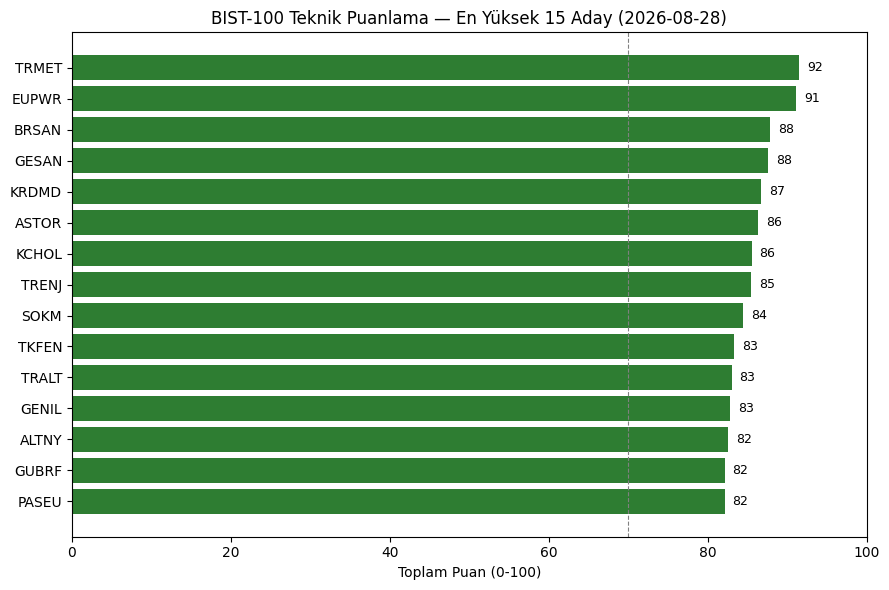

In [12]:
if top_list.empty:
    print(
        "Uyarı: Kapılardan geçen hiçbir aday yok (likidite/fiyat/veri tazeliği kapıları çok mu sıkı, "
        "yoksa veri kaynağında geniş çaplı bir sorun mu var - kontrol edin). Grafik atlanıyor."
    )
else:
    fig, ax = plt.subplots(figsize=(9, 6))
    plot_df = top_list.sort_values("score_total")
    colors = ["#2e7d32" if s >= 70 else "#f9a825" if s >= 50 else "#c62828" for s in plot_df["score_total"]]
    ax.barh(plot_df["symbol"], plot_df["score_total"], color=colors)
    ax.set_xlabel("Toplam Puan (0-100)")
    ax.set_title(f"BIST-100 Teknik Puanlama — En Yüksek {len(plot_df)} Aday ({top_list['as_of'].iloc[0]})")
    ax.set_xlim(0, 100)
    ax.axvline(70, color="gray", linestyle="--", linewidth=0.8)
    for i, (sym, score) in enumerate(zip(plot_df["symbol"], plot_df["score_total"])):
        ax.text(score + 1, i, f"{score:.0f}", va="center", fontsize=9)
    plt.tight_layout()
    plt.show()


## 9) Risk yönetimi — pozisyon büyüklüğü nasıl hesaplandı?

Yukarıdaki `suggested_shares` kolonu, kurumsal risk yönetiminde standart olan
**"sabit riskli pozisyon boyutlandırma"** (fixed-fractional position sizing)
kuralına dayanır:

```
işlem başına riske edilecek TL = Hesap Büyüklüğü × Risk Oranı (%1) × Rejim Çarpanı
riske edilen TL / hisse başına stop mesafesi (TL) = alınacak lot sayısı
```

**Neden bu şekilde?**

- **%1 risk kuralı**: Profesyonel risk yönetiminde yaygın kabul gören bir
  varsayılan — 10 işlemden 10'u da stop olsa bile hesabın ~%10'undan fazlası
  kaybedilmez. Bu, "büyük kazanacağım" beklentisiyle aşırı büyük pozisyon
  açıp birkaç kötü işlemde hesabı bitirme riskini yapısal olarak engeller.
- **ATR tabanlı stop**: Stop mesafesi sabit bir yüzde (ör. "%5 altında sat")
  yerine **hissenin kendi volatilitesine göre** (2 × ATR14) belirlenir. Zaten
  günlük %4-5 oynayan bir hissede %3'lük sabit bir stop, normal gürültüyle bile
  tetiklenir; buna karşın hesaplanan ATR mesafesi hissenin "doğal nefes alma
  payını" hesaba katar.
- **Rejim çarpanı**: RISK-OFF'ta risk oranı otomatik yarıya iner (Bölüm 4) —
  aynı %1 kuralını kör kör uygulamak yerine, genel piyasa riskliyken sermaye
  otomatik olarak korunur.
- **`MAX_CONCURRENT_POSITIONS`**: Tüm sermayeyi tek seferde en yüksek puanlı
  1-2 hisseye yatırmak yerine, `CONFIG["MAX_CONCURRENT_POSITIONS"]` kadar
  farklı hisseye (mümkünse farklı sektörlerden) dağıtılması önerilir —
  tek bir şirkete özgü haber riskini (kazanç şoku, KAP açıklaması vb.)
  azaltır.

> **Not:** Bu hesap sadece giriş anındaki riski büyüklüğe çevirir; kâr al
> seviyesi, trailing stop veya kısmi kâr realizasyonu gibi konular kasıtlı
> olarak bu notebook'un kapsamı dışında bırakıldı çünkü bunlar kişisel
> risk iştahına göre değişir ve tek bir "doğru" kural yoktur.


## 10) Geçmişte bu puanlamanın bir bilgi değeri var mıydı?

Bu bölüm **tam bir backtest değildir** (komisyon, kayma/slippage, gerçek
emir doldurma, BIST-100'ün geçmişteki gerçek bileşimi gibi detaylar dahil
değildir). Amaç çok daha mütevazı ve dürüst: *"Yüksek puanlı hisseler,
geçmişte düşük puanlılardan gerçekten daha mı iyi performans gösterdi?"*
sorusuna basit bir cevap vermek — kantitatif finansta buna **"faktör/sıralama
bilgi içeriği" (quintile spread) analizi** denir.

**Yöntem:**
1. Her hisse için puan zaman serisi zaten Bölüm 8'de hesaplandı (`panel`).
2. Yaklaşık her 21 işlem gününde bir (aylık dengeleme), o tarihte hesaplanmış
   puana göre **tüm evren o günkü kesitte 5 eşit gruba (beşte bir/quintile)**
   ayrılır — 0: en düşük puanlılar, 4: en yüksek puanlılar.
3. Her hisse için o tarihten **21 işlem günü sonrasına kadar** olan getiri
   hesaplanır (bu, puanın hesaplandığı günden SONRAKİ veriyi kullanır — puanın
   kendisi hiçbir zaman gelecek veriye bakmaz, sadece doğrulama ölçütü ileriye
   bakar, bu standart ve doğru bir yöntemdir).
4. Gruplar arasındaki ortalama ileri getiri karşılaştırılır. Eğer sistem
   gerçekten bilgi taşıyorsa, 4. grup (en yüksek puan) ortalamada 0. gruptan
   (en düşük puan) daha iyi getiri sağlamış olmalıdır.

**Bu analiz ne KANITLAMAZ:** Gelecekte de aynı ilişkinin süreceğini, gerçek
işlem maliyetleriyle kârlı olunacağını veya tek bir hissede kullanılabileceğini
(bu bir *kesitsel/çeşitlendirilmiş* ölçümdür) kanıtlamaz. Sadece puanlamanın
"rastgele gürültüden" farklı olup olmadığına dair bir sağlık kontrolüdür.


In [13]:
REBALANCE_EVERY = 21   # ~1 aylık dengeleme periyodu (işlem günü)
FORWARD_HORIZON = 21   # ileri getiri penceresi (işlem günü)

records = []
for ticker, merged in panel.items():
    valid = merged["ema200"].notna()
    fwd_ret = merged["Close"].shift(-FORWARD_HORIZON) / merged["Close"] - 1.0
    tmp = pd.DataFrame({"score": merged.loc[valid, "score_total"], "fwd_ret": fwd_ret.loc[valid]})
    tmp = tmp.iloc[::REBALANCE_EVERY].copy()
    tmp["ticker"] = ticker
    tmp["date"] = tmp.index
    records.append(tmp.dropna())

panel_long = pd.concat(records, ignore_index=True)
panel_long["quintile"] = panel_long.groupby("date")["score"].transform(
    lambda x: pd.qcut(x, 5, labels=False, duplicates="drop") if x.nunique() >= 5 else np.nan
)
panel_long = panel_long.dropna(subset=["quintile"])
panel_long["quintile"] = panel_long["quintile"].astype(int)

quintile_stats = panel_long.groupby("quintile")["fwd_ret"].agg(["mean", "median", "count"])
quintile_stats["mean_pct"] = quintile_stats["mean"] * 100
quintile_stats["median_pct"] = quintile_stats["median"] * 100
print(f"Dengeleme sayısı (tarih): {panel_long['date'].nunique()} | Gözlem sayısı: {len(panel_long)}\n")
print(quintile_stats[["count", "mean_pct", "median_pct"]].round(2))

spread = quintile_stats.loc[4, "mean_pct"] - quintile_stats.loc[0, "mean_pct"] if 4 in quintile_stats.index and 0 in quintile_stats.index else float("nan")
print(f"\nEn yüksek - en düşük puan grubu farkı (ortalama {FORWARD_HORIZON} günlük getiri): {spread:+.2f} puan")
print(
    "Pozitif ve tutarlı bir fark, puanlamanın rastgeleden farklı bir bilgi taşıdığına işaret eder.\n"
    "Negatif veya sıfıra yakın bir fark, ağırlıkların/eşiklerin (Bölüm 1) gözden geçirilmesi gerektiğinin sinyalidir."
)


Dengeleme sayısı (tarih): 22 | Gözlem sayısı: 2103

          count  mean_pct  median_pct
quintile                             
0           437      0.35        0.84
1           415      3.18        1.76
2           418      2.75        2.76
3           415      4.15        3.36
4           418      5.40        3.50

En yüksek - en düşük puan grubu farkı (ortalama 21 günlük getiri): +5.06 puan
Pozitif ve tutarlı bir fark, puanlamanın rastgeleden farklı bir bilgi taşıdığına işaret eder.
Negatif veya sıfıra yakın bir fark, ağırlıkların/eşiklerin (Bölüm 1) gözden geçirilmesi gerektiğinin sinyalidir.


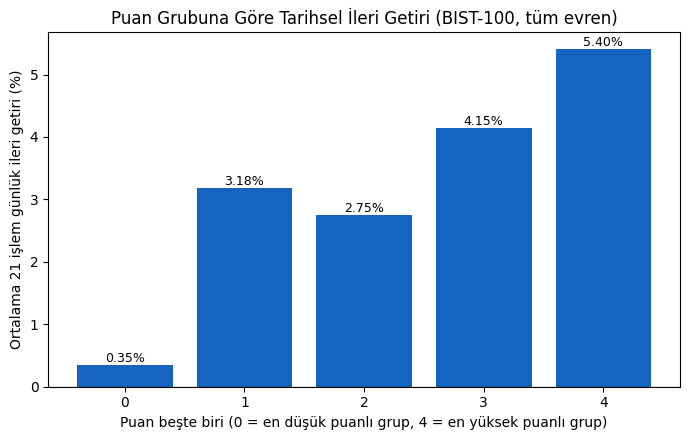

In [14]:
fig, ax = plt.subplots(figsize=(7, 4.5))
bars = ax.bar(quintile_stats.index.astype(str), quintile_stats["mean_pct"], color="#1565c0")
ax.set_xlabel("Puan beşte biri (0 = en düşük puanlı grup, 4 = en yüksek puanlı grup)")
ax.set_ylabel(f"Ortalama {FORWARD_HORIZON} işlem günlük ileri getiri (%)")
ax.set_title("Puan Grubuna Göre Tarihsel İleri Getiri (BIST-100, tüm evren)")
ax.axhline(0, color="black", linewidth=0.8)
for bar, val in zip(bars, quintile_stats["mean_pct"]):
    ax.text(bar.get_x() + bar.get_width() / 2, val, f"{val:.2f}%", ha="center",
            va="bottom" if val >= 0 else "top", fontsize=9)
plt.tight_layout()
plt.show()


## 11) Kullanım kılavuzu — ne zaman, nasıl, neye dikkat?

### Ne zaman çalıştırılmalı?
- **Seans kapanışından sonra** (TSİ ~18:10 ve sonrası) çalıştırın. BIST günlük
  seansı 18:00'de kapanır; kapanmadan çalıştırırsanız günün barı henüz
  tamamlanmamış olur ve göstergeler (özellikle hacim oranı, gün sonu
  mumu) yanıltıcı olabilir.
- Günlük bar kullanıldığı için bu sistem **swing trading ufku** (günler-haftalar)
  için tasarlandı. **Gün içi scalping için uygun değildir** — o amaç için
  farklı bir zaman dilimi ve farklı bir risk çerçevesi gerekir.
- Haftada 2-3 kez çalıştırmak (ör. Pazartesi, Çarşamba, Cuma kapanışı sonrası)
  günlük değişimleri gereksiz yere kovalamadan güncel kalmak için yeterlidir.

### Çıktı nasıl yorumlanır?
1. Önce **Bölüm 4'teki piyasa rejimini** okuyun — bu, listeye ne kadar
   agresif yaklaşacağınızı belirler.
2. **Bölüm 8'deki sıralı listeye** bakın. Puan bir "kesinlik" değil, göreceli
   bir **çekicilik sıralamasıdır**. 70+ puan güçlü teknik görünüm, 50-70 orta,
   50 altı zayıftır.
3. Alt puan kırılımını (`score_trend`, `score_momentum`, `score_rs`,
   `score_volume`) inceleyin — örneğin trend puanı yüksek ama hacim puanı
   düşükse, "fiyat yükseliyor ama katılım zayıf" demektir; bu ek dikkat
   gerektirir.
4. Listedeki her hisseyi **kendi ek analizinizle teyit edin**: KAP
   duyuruları, sektör haberleri, yaklaşan bilanço tarihleri. Bu sistem
   sadece fiyat/hacim verisine bakar; haber/temel analiz riskini görmez.
5. `stop_price` ve `suggested_shares` kolonlarını **giriş kararınızı
   verdikten sonra** bir başlangıç noktası olarak kullanın; bunlar kesin
   emir değil, disiplinli bir risk çerçevesi önerisidir.

### Bakım
- `BIST100_SYMBOLS` listesini çeyreklik olarak Borsa İstanbul'un resmi endeks
  bileşim duyurularına göre güncelleyin.
- `CONFIG` içindeki ağırlıkları/eşikleri değiştirdiyseniz, Bölüm 10'daki
  beşte birlik analizi tekrar çalıştırıp spread'in bozulup bozulmadığını
  kontrol edin.
- `MIN_AVG_TURNOVER_TRY` değerini kendi tipik işlem büyüklüğünüze göre ayarlayın
  (küçük hesaplar daha düşük likidite eşiğiyle de güvenle işlem yapabilir).

### Bilinen sınırlamalar (dürüstçe)
- **Hayatta kalma yanlılığı**: `BIST100_SYMBOLS` bugünkü (veya son güncellenen)
  bileşimdir; geçmiş dönemlerde endekste olmayan/sonradan çıkan hisseler
  Bölüm 10'daki analize dahil değildir.
- **Kayma/komisyon dahil değil**: Gerçek işlemde spread, komisyon ve kayma
  (slippage) getiriyi azaltır; Bölüm 10'daki sayılar brüttür.
- **Temel analiz / haber akışı yok**: Sistem sadece fiyat, hacim ve endeks
  verisine bakar; bilanço, KAP haberleri, sektörel gelişmeler dahil değildir.
- **Yatırım tavsiyesi değildir**: Bu araç bir ön-eleme/sıralama aracıdır;
  nihai yatırım kararı ve bundan doğacak risk tamamen kullanıcıya aittir.


## 12) (Opsiyonel) Sonuçları kaydet

Taramanın bir kopyasını CSV olarak kaydedin — özellikle Google Drive'a bağlıysanız
zaman içindeki taramaları karşılaştırmak için faydalıdır.


In [15]:
from datetime import datetime

out_path = f"bist100_tarama_{datetime.now():%Y%m%d_%H%M}.csv"
top_list[display_cols].round(2).to_csv(out_path, index=False, encoding="utf-8-sig")
print(f"Kaydedildi: {out_path}")

try:
    from google.colab import files as colab_files
    colab_files.download(out_path)
except ImportError:
    print("(Google Colab dışında çalışıyorsunuz; dosya yerel dizine kaydedildi.)")


Kaydedildi: bist100_tarama_20260828_1226.csv


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>